# 027 批次反向传播与损失归约

目标：从同一个标量mean CE出发，用矩阵反传、逐样本标量求和和全坐标有限差分核对2→3→2→3网络。5条原创合成数据，26个参数，无训练框架和网络请求。

已执行摘要：mean CE约1.1489788656，26坐标差分通过；2+3微批按大小加权一致，简单平均梯度有约0.03308的最大坐标错误。单步下降仅是固定夹具结果，不说明泛化或一般收敛。

请在本单元目录重启内核后顺序运行。默认资料校验在第一格完成；自定义实验另存输出，不使用固定解释。

In [1]:
from pathlib import Path
from make_figures import verify_default
verify_default()
print('Default inputs and five reference outputs verified.')

Default inputs and five reference outputs verified.


## 1 环境与固定输入
真实InProcessKernel可执行；没有验证浏览器Jupyter、socket传输、全新Anaconda或GPU。

In [2]:
import sys, json, csv, tempfile, subprocess
import numpy as np
from IPython.display import display, Image
import experiment as e
print({'Python': sys.version.split()[0], 'NumPy': np.__version__})
ids, X, y, params, cfg = e.load_inputs()
for ident, x, label in zip(ids, X, y):
    print(ident, x.tolist(), int(label))

{'Python': '3.12.14', 'NumPy': '2.3.5'}
s1 [-1.0, 0.5] 0
s2 [0.25, -0.75] 1
s3 [1.0, 0.0] 2
s4 [-0.5, -1.0] 1
s5 [0.75, 1.0] 0


## 2 每层形状与目标
缓存H保存本层输入，Z保存激活前值，delta均针对同一个平均损失。

In [3]:
r = e.loss_and_grad(X, y, params, cfg['activation'])
for j, p in enumerate(params):
    print(j+1, 'H:', r['H'][j].shape, 'Z/D:', r['Z'][j].shape,
          r['delta'][j].shape, 'dW/db:',
          r['grads'][j]['W'].shape, r['grads'][j]['b'].shape)
print('loss =', r['loss'], '; parameters =', len(e.flat(r['grads'])))

1 H: (5, 2) Z/D: (5, 3) (5, 3) dW/db: (2, 3) (3,)
2 H: (5, 3) Z/D: (5, 2) (5, 2) dW/db: (3, 2) (2,)
3 H: (5, 2) Z/D: (5, 3) (5, 3) dW/db: (2, 3) (3,)
loss = 1.148978865605775 ; parameters = 26


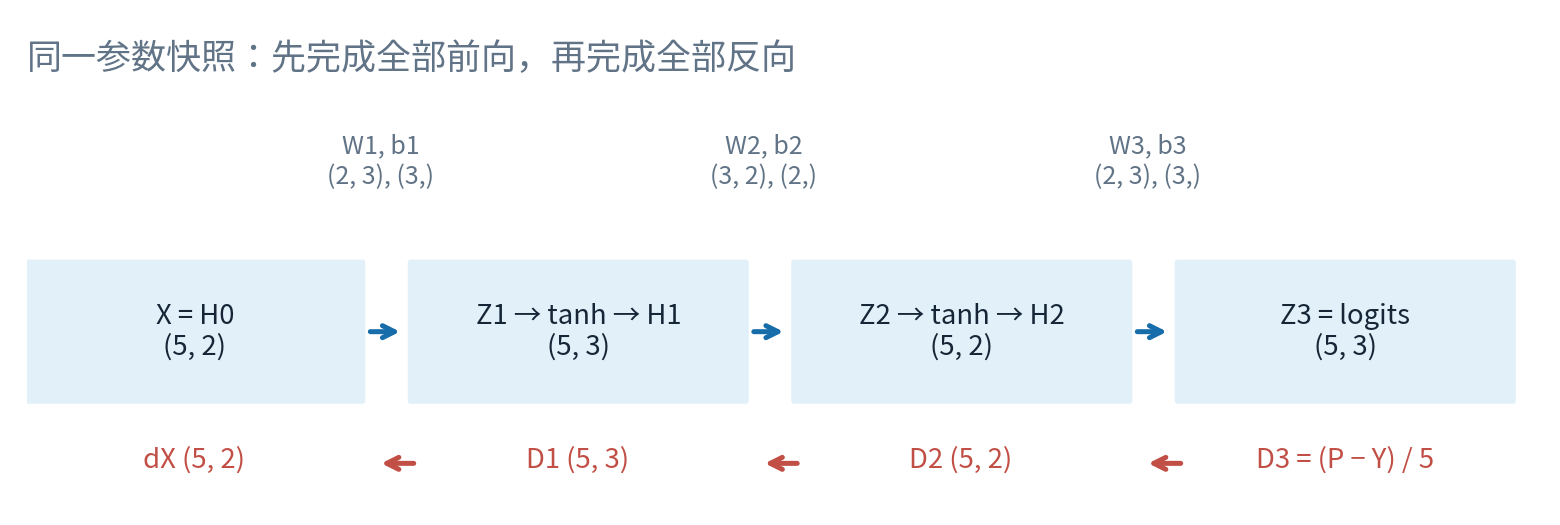

In [4]:
display(Image(data=Path('figures/01_shapes.png').read_bytes()))

## 3 完整手算网络
所有隐藏激活大于0，ReLU折点不会影响这次全坐标差分。目标是两条CE的mean。

In [5]:
hand_X = np.array([[1., 2.], [-1., 1.]])
hand_p = [
    {'W': np.array([[1., 1.], [0., 0.]]), 'b': np.array([2., 2.])},
    {'W': np.array([[1., -1.], [-1., 1.]]), 'b': np.zeros(2)}]
hand = e.loss_and_grad(hand_X, [0, 0], hand_p, 'relu')
np.testing.assert_array_equal(hand['grads'][0]['W'], [[0, 0], [-1.5, 1.5]])
np.testing.assert_array_equal(hand['grads'][0]['b'], [-1, 1])
np.testing.assert_array_equal(hand['grads'][1]['W'], [[-1, 1], [-1, 1]])
np.testing.assert_array_equal(hand['grads'][1]['b'], [-.5, .5])
np.testing.assert_array_equal(hand['dX'], np.zeros((2, 2)))
print('hand CE:', hand['loss'], '; full analytic expectations match')
for j, g in enumerate(hand['grads']):
    print('layer', j+1, {k:v.tolist() for k,v in g.items()})

hand CE: 0.6931471805599453 ; full analytic expectations match
layer 1 {'W': [[0.0, 0.0], [-1.5, 1.5]], 'b': [-1.0, 1.0]}
layer 2 {'W': [[-1.0, 1.0], [-1.0, 1.0]], 'b': [-0.5, 0.5]}


## 4 逐样本标量核验与归约倍率
标量参考另写循环，不调用矩阵反传；每行是一个样本未平均的26维导数。

In [6]:
sample_grads = e.scalar_sample_oracle(X, y, params)
g = e.flat(r['grads'])
gsum = e.flat(e.loss_and_grad(X, y, params, reduction='sum')['grads'])
np.testing.assert_allclose(sample_grads.mean(axis=0), g, rtol=2e-12, atol=2e-14)
np.testing.assert_allclose(gsum, len(X)*g, rtol=2e-12, atol=2e-14)
print('sample-gradient shape:', sample_grads.shape)
print('scalar mean max error:', np.max(np.abs(sample_grads.mean(0)-g)))
print('sum vs n*mean:', np.max(np.abs(gsum-len(X)*g)))

sample-gradient shape: (5, 26)
scalar mean max error: 3.469446951953614e-17
sum vs n*mean: 1.6653345369377348e-16


## 5 逐参数中心差分
相对误差有1e−8分母地板；通过判据同时包含绝对与相对容差。全部26个坐标显示，不只显示通过者。

In [7]:
fd = e.finite_difference(X, y, params, h=cfg['fd_h'])
for row in fd:
    print(row['parameter'], f"analytic={row['analytic']:.10g}",
          f"numeric={row['numeric']:.10g}",
          f"abs={row['absolute_error']:.3g}",
          f"rel={row['relative_error']:.3g}", row['pass'])
if not all(row['pass'] for row in fd):
    raise RuntimeError('Default all-coordinate gradient check failed')
print('worst absolute-error coordinate:', max(fd, key=lambda row: row['absolute_error']))

W1[0,0] analytic=0.001801020565 numeric=0.001801020566 abs=1.19e-12 rel=3.31e-10 True
W1[0,1] analytic=-0.02143155979 numeric=-0.02143155978 abs=3.49e-12 rel=8.15e-11 True
W1[0,2] analytic=-0.02145619879 numeric=-0.0214561988 abs=5.57e-12 rel=1.3e-10 True
W1[1,0] analytic=-0.08644357821 numeric=-0.08644357822 abs=8.87e-12 rel=5.13e-11 True
W1[1,1] analytic=-0.05044969272 numeric=-0.0504496927 abs=1.44e-11 rel=1.43e-10 True
W1[1,2] analytic=0.09173954859 numeric=0.0917395486 abs=7.96e-12 rel=4.34e-11 True
b1[0] analytic=-0.0009517944286 numeric=-0.0009517944322 abs=3.55e-12 rel=1.86e-09 True
b1[1] analytic=0.02532042832 numeric=0.02532042831 abs=1.25e-11 rel=2.48e-10 True
b1[2] analytic=-0.006357324929 numeric=-0.006357324933 abs=4e-12 rel=3.14e-10 True
W2[0,0] analytic=0.07407375585 numeric=0.07407375584 abs=8.29e-12 rel=5.59e-11 True
W2[0,1] analytic=-0.07953018431 numeric=-0.0795301843 abs=2.04e-13 rel=1.28e-12 True
W2[1,0] analytic=-0.01857107817 numeric=-0.01857107818 abs=9.01e-12 

## 6 重新生成可对照产物
写notebook_outputs，不覆盖随附outputs。所有输入检查、计算和序列化先于最终文件替换。

In [8]:
summary = e.run(output=Path('notebook_outputs'))
print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "n": 5,
  "widths": [
    2,
    3,
    2,
    3
  ],
  "activation": "tanh",
  "parameter_count": 26,
  "mean_loss": 1.148978865605775,
  "sum_loss": 5.744894328028874,
  "gradient_norm": 0.2782642895824935,
  "sum_vs_n_mean_max_error": 1.6653345369377348e-16,
  "samples_vs_mean_max_error": 3.469446951953614e-17,
  "microbatch_sizes": [
    2,
    3
  ],
  "weighted_microbatch_max_error": 3.122502256758253e-17,
  "unweighted_microbatch_max_error": 0.03307739850815247,
  "fd_h": 1e-05,
  "fd_max_absolute_error": 1.7971457655363565e-11,
  "fd_max_relative_error": 1.8646326403589515e-09,
  "fd_all_pass": true,
  "learning_rate": 0.1,
  "after_one_step_loss": 1.1413798716255645,
  "scope": "synthetic fixed-batch derivative checks; no generalization or convergence claim"
}


In [9]:
for name in e.OUTPUT_NAMES:
    if (Path('notebook_outputs')/name).read_bytes() != (Path('outputs')/name).read_bytes():
        raise RuntimeError('Script/Notebook bytes differ: '+name)
print('All five files match the fresh-script reference byte for byte in this environment.')

All five files match the fresh-script reference byte for byte in this environment.


## 7 微批：按2/5与3/5组合
所有微批使用同一参数快照，计算完成前不更新。

In [10]:
ga = e.flat(e.loss_and_grad(X[:2], y[:2], params)['grads'])
gb = e.flat(e.loss_and_grad(X[2:], y[2:], params)['grads'])
weighted = .4*ga + .6*gb
wrong = .5*(ga+gb)
np.testing.assert_allclose(weighted, g, rtol=2e-12, atol=2e-14)
print('weighted max error:', np.max(np.abs(weighted-g)))
print('unweighted max error:', np.max(np.abs(wrong-g)))
dup = e.flat(e.loss_and_grad(np.repeat(X,3,0), np.repeat(y,3), params)['grads'])
np.testing.assert_allclose(dup, g, rtol=2e-12, atol=2e-14)
print('Duplicating the entire batch 3 times leaves mean gradient unchanged.')

weighted max error: 3.122502256758253e-17
unweighted max error: 0.03307739850815247
Duplicating the entire batch 3 times leaves mean gradient unchanged.


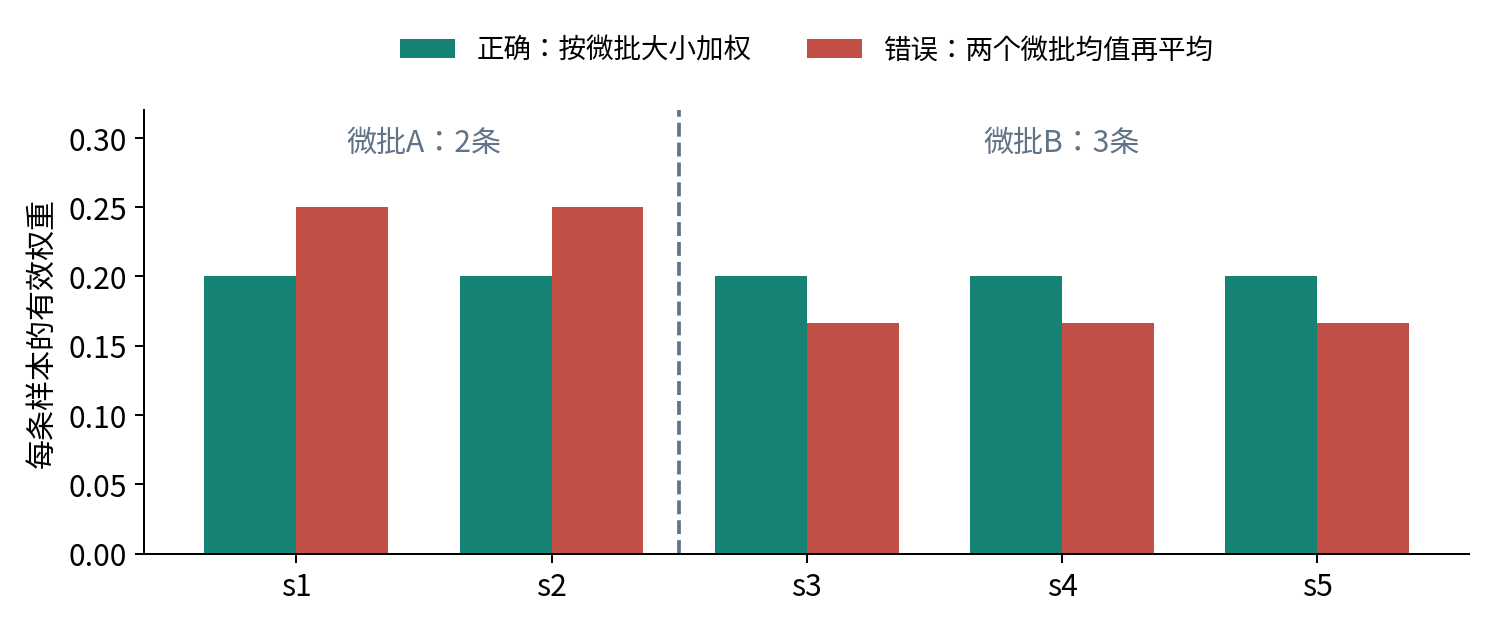

In [11]:
display(Image(data=Path('figures/06_microbatch_weights.png').read_bytes()))

## 8 广播反向与同shape错轴
广播复制了使用路径，反向恢复原shape。错轴在方形批次里可能形状完全合法。

In [12]:
G = np.arange(24.).reshape(2,3,4)
for shape in [(4,), (3,1), (1,3,1), ()]:
    print(shape, '->', e.unbroadcast(G, shape).tolist())
_, delta, _, _ = e.cross_entropy(np.zeros((3,3)), [0,0,1])
print('correct db:', delta.sum(axis=0))
print('wrong axis:', delta.sum(axis=1))
print('ReLU centered difference at zero:', (max(1e-5,0)-max(-1e-5,0))/(2e-5))

(4,) -> [60.0, 66.0, 72.0, 78.0]
(3, 1) -> [[60.0], [92.0], [124.0]]
(1, 3, 1) -> [[[60.0], [92.0], [124.0]]]
() -> 276.0
correct db: [-0.33333333  0.          0.33333333]
wrong axis: [0. 0. 0.]
ReLU centered difference at zero: 0.5


## 9 步长扫描
较小h可能导致相减舍入误差增长；ReLU折点不是普通可微点。图来自上述相同默认结果。

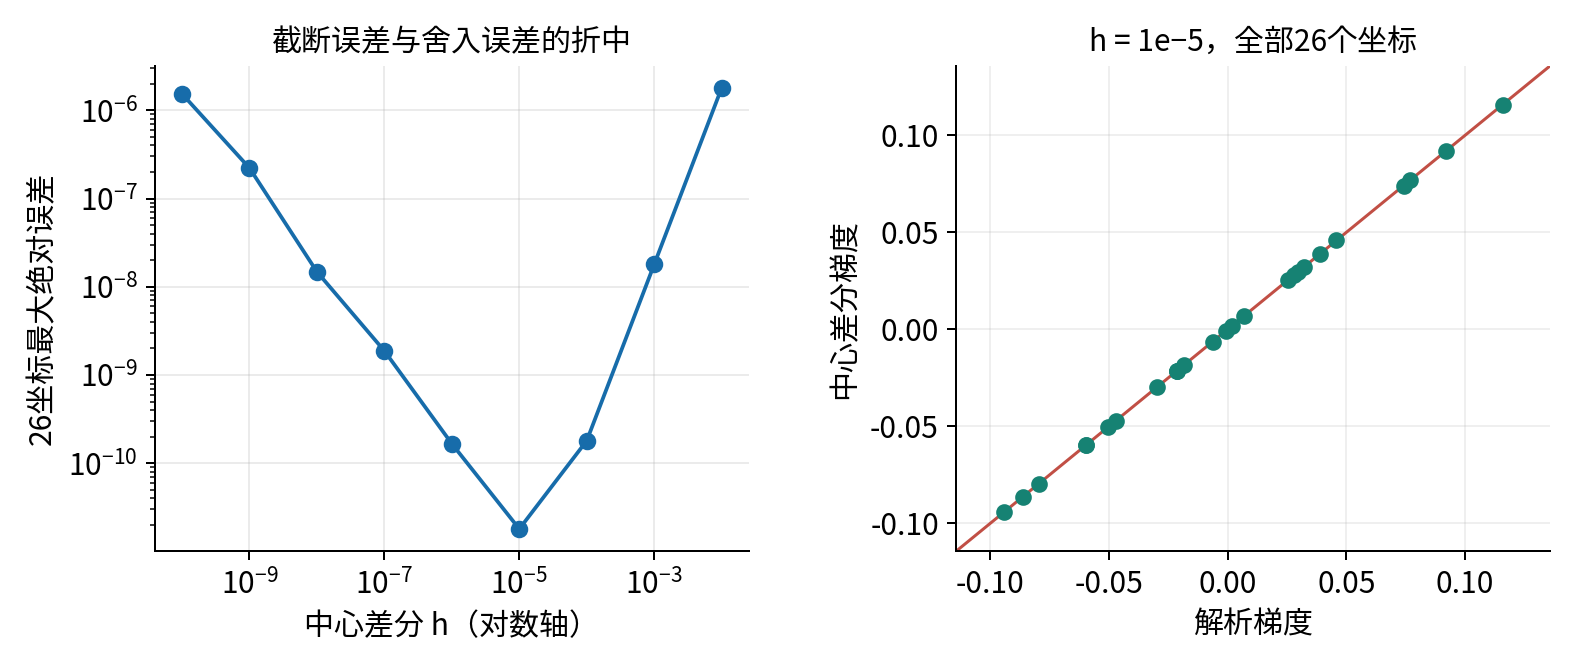

In [13]:
display(Image(data=Path('figures/08_finite_difference.png').read_bytes()))

## 10 错误输入不会产生新结果
该测试在临时副本上进行，不改正式数据。已有结果保护由完整测试另外覆盖。

In [14]:
with tempfile.TemporaryDirectory() as temporary:
    root = Path(temporary)
    bad = root/'bad.csv'
    bad.write_text(Path('data/batch.csv').read_text().replace('s1,-1,0.5,0', 's1,1e-400,0.5,0'))
    try:
        e.run(data=bad, output=root/'new_outputs')
    except ValueError as exc:
        print('Rejected:', str(exc))
    else:
        raise RuntimeError('Malformed input was accepted')
    if (root/'new_outputs').exists():
        raise RuntimeError('Input failure created final outputs')
print('Failure isolation check passed.')

Rejected: nonfinite or nonzero-to-zero numeric text
Failure isolation check passed.


## 11 独立参考完整测试
72个70位Decimal前向求导网络、36组全参数/输入差分、150组极端CE参考、手算、广播与新旧结果保护。

In [15]:
test = subprocess.run([sys.executable, 'test_experiment.py'], capture_output=True, text=True)
if test.returncode:
    raise RuntimeError(test.stdout + test.stderr)
print(test.stderr.strip())

test_all_parameter_fd_and_input_fd (__main__.Tests.test_all_parameter_fd_and_input_fd) ... ok
test_bad_input_does_not_touch_outputs (__main__.Tests.test_bad_input_does_not_touch_outputs) ... ok
test_calculation_failure_isolation (__main__.Tests.test_calculation_failure_isolation) ... ok
test_ce_decimal_extreme (__main__.Tests.test_ce_decimal_extreme) ... ok
test_decimal_forward_mode_networks (__main__.Tests.test_decimal_forward_mode_networks) ... ok
test_fraction_affine_and_broadcast (__main__.Tests.test_fraction_affine_and_broadcast) ... ok
test_hand_network (__main__.Tests.test_hand_network) ... ok
test_invalid_math_and_conversion (__main__.Tests.test_invalid_math_and_conversion) ... ok
test_reductions_permutations_duplicates_and_chunks (__main__.Tests.test_reductions_permutations_duplicates_and_chunks) ... ok
test_relu_kink_is_not_smooth_fd (__main__.Tests.test_relu_kink_is_not_smooth_fd) ... ok
test_reproducible_and_no_mutation (__main__.Tests.test_reproducible_and_no_mutation) ...

## 结论与下一步

默认26参数反传通过独立核验，归约因子与广播轴是关键。5样本拆2+3时必须按大小加权；零logits的3×3反例说明shape正确仍可能轴语义错误。

完整12题与实验答案见answers.pdf。若修改数据或配置，应另存并重新推导预期，不绕过默认图的校验去沿用原结论。来源见sources.md；本Notebook没有执行PyTorch或自动微分框架。